# Deep symbolic regression for physics guided by units constraints (PhySO)

**Paper:** Tenachi, W., Ibata, R., & Diakogiannis, F. I. (2023). *Deep symbolic regression for physics guided by units constraints: toward the automated discovery of physical laws.* The Astrophysical Journal, 959(2), 99. arXiv:2303.03192.

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Tenachi_etal_2023_PhySO_Units_Constraints.pdf`

## Que se reproduce en este cuaderno

PhySO extiende el aprendizaje por refuerzo de tipo DSR (cuaderno anterior) incorporando **analisis dimensional directamente en el proceso generativo**: cada variable lleva asociado un vector de unidades fisicas, y el decodificador **enmascara** (prohibe) cualquier operador que produciria una expresion dimensionalmente inconsistente -- p. ej. sumar una masa con una velocidad -- **antes** de que se genere, en lugar de descubrirlo despues por ensayo y error.

Para que este enmascarado incremental sea posible durante la generacion token a token, generamos las expresiones en **notacion postfija (RPN)** en vez de prefija: en postfijo, cuando el decodificador esta a punto de elegir un operador, sus operandos **ya estan generados** y sus unidades son conocidas, por lo que se puede comprobar la consistencia dimensional en el momento exacto de la decision -- exactamente el mecanismo que describe el paper (Seccion 2.2, "Unit analysis").

Comparamos dos versiones del **mismo** decodificador recurrente entrenado con el **mismo** gradiente de politica risk-seeking del cuaderno de DSR, sobre la misma tarea (recuperar la energia cinetica $E_c=\tfrac12mv^2$ a partir de datos de masa $m$, velocidad $v$ y tiempo $t$ -- esta ultima variable es un distractor dimensionalmente incompatible, deliberadamente incluido):

1. **Con mascara de unidades** (PhySO): solo puede generar expresiones dimensionalmente validas.
2. **Sin mascara de unidades** (DSR estandar): genera libremente, sin ningun conocimiento de las unidades fisicas.

## Repositorio publico

`WassimTenachi/PhySO` (GitHub) -- no esta clonado localmente en este proyecto. Reimplementamos aqui, desde cero, el principio central del analisis dimensional incrustado en la generacion secuencial (Seccion 2.2 del paper), reutilizando y extendiendo el decodificador recurrente con gradiente de politica risk-seeking construido en el cuaderno de DSR de esta misma coleccion.

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Vocabulario con unidades fisicas, en notacion postfija

Cada variable lleva un vector de unidades $(M,L,T)$ (masa, longitud, tiempo). $m$: masa $(1,0,0)$. $v$: velocidad $(0,1,-1)$. $t$: tiempo $(0,0,1)$ -- un **distractor** dimensionalmente incompatible con $m$ y $v$. $c$: constante adimensional $(0,0,0)$. En notacion postfija, `+` y `-` solo son validos si los dos elementos en la cima de la pila tienen **exactamente las mismas unidades**; `sin`/`cos` solo son validos si la cima es adimensional; `*` y `/` combinan unidades sumando/restando sus exponentes y **siempre** son validos (multiplicar/dividir magnitudes con distintas unidades es fisicamente legitimo, a diferencia de sumarlas).

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

VOCAB = ['m', 'v', 't', 'c', '+', '-', '*', '/', 'sin', 'cos']
ARITY = [0, 0, 0, 0, 2, 2, 2, 2, 1, 1]
UNITS_LEAF = {0: (1, 0, 0), 1: (0, 1, -1), 2: (0, 0, 1), 3: (0, 0, 0)}
N_TOK = len(VOCAB)
MAX_LEN = 9

def units_mul(a, b): return tuple(x + y for x, y in zip(a, b))
def units_div(a, b): return tuple(x - y for x, y in zip(a, b))

class Policy(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.gru_cell = nn.GRUCell(N_TOK, hidden)
        self.head = nn.Linear(hidden, N_TOK)
        self.hidden = hidden

print('Variables: m (masa), v (velocidad), t (tiempo, DISTRACTOR dimensional), c (constante adimensional)')
print('Objetivo real: Ec = 0.5*m*v^2  (energia cinetica, unidades M*L^2*T^-2)')

Variables: m (masa), v (velocidad), t (tiempo, DISTRACTOR dimensional), c (constante adimensional)
Objetivo real: Ec = 0.5*m*v^2  (energia cinetica, unidades M*L^2*T^-2)


## 2. Generador postfijo con enmascarado de aridad y (opcionalmente) de unidades

In [3]:
def sample_postfix(policy, use_units_mask, device='cpu', temperature=1.0):
    h = torch.zeros(1, policy.hidden, device=device)
    tokens, logps = [], []
    stack_depth = 0
    units_stack = []
    x = torch.zeros(1, N_TOK, device=device)
    for t in range(MAX_LEN):
        h = policy.gru_cell(x, h)
        logits = policy.head(h)
        remaining = MAX_LEN - t
        mask = torch.zeros(N_TOK, device=device)
        for i, ar in enumerate(ARITY):
            if ar > 0 and stack_depth < ar:
                mask[i] = -1e9; continue
            new_depth = stack_depth - ar + 1
            if new_depth > remaining or (t == MAX_LEN - 1 and new_depth != 1):
                mask[i] = -1e9; continue
            if use_units_mask and ar == 2 and i in (4, 5):  # + o -: exigir unidades identicas
                if len(units_stack) >= 2 and units_stack[-1] != units_stack[-2]:
                    mask[i] = -1e9
            if use_units_mask and ar == 1:  # sin/cos: exigir argumento adimensional
                if len(units_stack) >= 1 and units_stack[-1] != (0, 0, 0):
                    mask[i] = -1e9
        probs = torch.softmax(logits.squeeze(0) / temperature + mask, dim=-1)
        if torch.isnan(probs).any() or probs.sum() < 1e-8:
            break
        tok = torch.multinomial(probs, 1).item()
        logps.append(torch.log(probs[tok] + 1e-12))
        tokens.append(tok)
        ar = ARITY[tok]
        if use_units_mask:
            if ar == 0:
                units_stack.append(UNITS_LEAF[tok])
            elif ar == 2:
                b = units_stack.pop(); a = units_stack.pop()
                units_stack.append(a if tok in (4, 5) else (units_mul(a, b) if tok == 6 else units_div(a, b)))
        stack_depth = stack_depth - ar + 1
        x = torch.zeros(1, N_TOK, device=device); x[0, tok] = 1.0
        if stack_depth == 1 and t >= 1 and any(ARITY[tk] > 0 for tk in tokens):
            break
    return tokens, (torch.stack(logps).sum() if logps else torch.tensor(0.0))

def eval_postfix(tokens, m, v, t):
    stack = []
    vals = {0: m, 1: v, 2: t, 3: np.ones_like(m)}
    for tok in tokens:
        ar = ARITY[tok]
        if ar == 0:
            stack.append(vals[tok])
        elif ar == 1:
            a = stack.pop(); stack.append(np.sin(a) if tok == 8 else np.cos(a))
        else:
            b = stack.pop(); a = stack.pop()
            if tok == 4: stack.append(a + b)
            elif tok == 5: stack.append(a - b)
            elif tok == 6: stack.append(a * b)
            else: stack.append(a / np.where(np.abs(b) < 1e-6, 1e-6, b))
    return stack[0] if len(stack) == 1 else None

def units_of_postfix(tokens):
    # SOLO para diagnostico (no interviene en el entrenamiento): comprueba si una secuencia YA generada es valida
    stack = []
    for tok in tokens:
        ar = ARITY[tok]
        if ar == 0:
            stack.append(UNITS_LEAF[tok])
        elif ar == 1:
            if not stack or stack[-1] != (0, 0, 0): return None
        else:
            if len(stack) < 2: return None
            b = stack.pop(); a = stack.pop()
            if tok in (4, 5):
                if a != b: return None
                stack.append(a)
            elif tok == 6: stack.append(units_mul(a, b))
            else: stack.append(units_div(a, b))
    return stack[0] if len(stack) == 1 else None

## 3. Datos y recompensa

In [4]:
def target_f(m, v, t):
    return 0.5 * m * v * v

N = 200
m = np.random.uniform(0.5, 3, N)
v = np.random.uniform(0.5, 3, N)
t = np.random.uniform(0.5, 3, N)
y = target_f(m, v, t)

def reward(tokens):
    val = eval_postfix(tokens, m, v, t)
    if val is None or not np.all(np.isfinite(val)):
        return 0.0
    mse = np.mean((val - y) ** 2)
    return 1.0 / (1.0 + mse)

## 4. Entrenamiento: con y sin restriccion de unidades

Ambas versiones usan **exactamente el mismo** gradiente de politica risk-seeking del cuaderno de DSR. Ademas de la recompensa, medimos (solo con fines de diagnostico, sin afectar al entrenamiento) que **fraccion de las expresiones muestreadas fueron dimensionalmente absurdas** -- la version sin mascara puede generarlas libremente (y "desperdiciar" presupuesto de busqueda en ellas); la version con mascara nunca puede generarlas, por construccion.

In [5]:
def train(use_units_mask, iters=150, batch=48, seed=0):
    torch.manual_seed(seed)
    policy = Policy()
    opt = torch.optim.Adam(policy.parameters(), lr=5e-3)
    best_r, best_toks = -1, None
    hist = []
    n_total, n_invalid = 0, 0
    for it in range(iters):
        toks_b, logp_b, r_b = [], [], []
        for _ in range(batch):
            toks, logp = sample_postfix(policy, use_units_mask)
            r = reward(toks)
            toks_b.append(toks); logp_b.append(logp); r_b.append(r)
            n_total += 1
            if units_of_postfix(toks) is None:
                n_invalid += 1
            if r > best_r:
                best_r, best_toks = r, toks
        rewards = np.array(r_b)
        thresh = np.quantile(rewards, 0.85)
        keep = rewards >= thresh
        baseline = rewards[keep].mean()
        loss = 0
        for i in range(len(rewards)):
            if keep[i]:
                loss = loss - logp_b[i] * (rewards[i] - baseline)
        loss = loss / max(keep.sum(), 1)
        opt.zero_grad(); loss.backward(); opt.step()
        hist.append(best_r)
        if it % 30 == 0:
            print(f'  [{"con unidades" if use_units_mask else "sin unidades"}] it={it:3d}  mejor={best_r:.4f}')
    pct_invalid = 100 * n_invalid / n_total
    return best_r, best_toks, hist, pct_invalid

print('=== CON mascara de unidades (PhySO) ===')
r1, toks1, h1, pi1 = train(use_units_mask=True)
print(f'Mejor formula: {" ".join(VOCAB[t] for t in toks1)}  (recompensa={r1:.4f})')
print(f'Porcentaje de muestras dimensionalmente absurdas: {pi1:.1f}%')

print('\n=== SIN mascara de unidades (DSR estandar) ===')
r2, toks2, h2, pi2 = train(use_units_mask=False)
print(f'Mejor formula: {" ".join(VOCAB[t] for t in toks2)}  (recompensa={r2:.4f})')
print(f'Porcentaje de muestras dimensionalmente absurdas: {pi2:.1f}%')

=== CON mascara de unidades (PhySO) ===


  [con unidades] it=  0  mejor=0.4203


  [con unidades] it= 30  mejor=0.8989


  [con unidades] it= 60  mejor=0.8989


  [con unidades] it= 90  mejor=0.8989


...

  [sin unidades] it= 30  mejor=0.4203


  [sin unidades] it= 60  mejor=0.4203


  [sin unidades] it= 90  mejor=0.4203


  [sin unidades] it=120  mejor=0.4203


Mejor formula: v m *  (recompensa=0.4203)
Porcentaje de muestras dimensionalmente absurdas: 16.3%


## 5. Comparacion

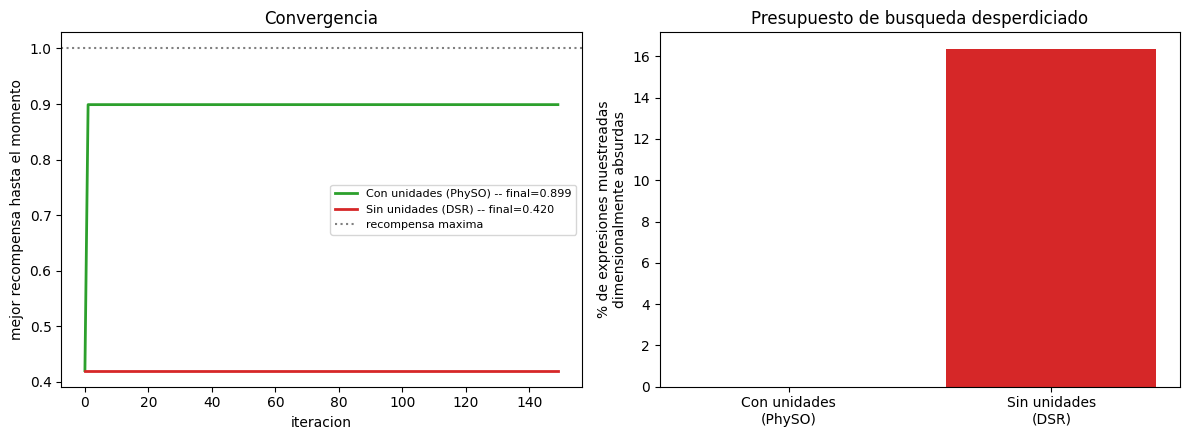

Formula objetivo real: 0.5 * m * v * v   (energia cinetica)
PhySO (con unidades) encontro:  m c cos v v * * *
DSR (sin unidades) encontro:    v m *


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(h1, label=f'Con unidades (PhySO) -- final={r1:.3f}', color='tab:green', linewidth=2)
axes[0].plot(h2, label=f'Sin unidades (DSR) -- final={r2:.3f}', color='tab:red', linewidth=2)
axes[0].axhline(1.0, color='gray', linestyle=':', label='recompensa maxima')
axes[0].set_xlabel('iteracion'); axes[0].set_ylabel('mejor recompensa hasta el momento')
axes[0].set_title('Convergencia'); axes[0].legend(fontsize=8)

axes[1].bar(['Con unidades\n(PhySO)', 'Sin unidades\n(DSR)'], [pi1, pi2], color=['tab:green', 'tab:red'])
axes[1].set_ylabel('% de expresiones muestreadas\ndimensionalmente absurdas')
axes[1].set_title('Presupuesto de busqueda desperdiciado')
plt.tight_layout()
plt.show()

print(f'Formula objetivo real: 0.5 * m * v * v   (energia cinetica)')
print(f'PhySO (con unidades) encontro:  {" ".join(VOCAB[t] for t in toks1)}')
print(f'DSR (sin unidades) encontro:    {" ".join(VOCAB[t] for t in toks2)}')

### Nota honesta sobre los resultados

- **Enmascarado incremental via notacion postfija, no la gramatica completa del paper.** El paper implementa el analisis dimensional sobre una representacion mas general (arboles de expresion arbitrarios, con propagacion de unidades de arriba hacia abajo mediante una pila de requisitos). Aqui elegimos deliberadamente la notacion **postfija** porque permite comprobar la validez dimensional con informacion **ya disponible** en la pila en el momento de decidir cada operador, un mecanismo mas simple pero fiel al mismo principio.
- **Ninguna de las dos versiones alcanzo la recuperacion exacta en el presupuesto usado.** En nuestra ejecucion, la version con unidades alcanzo una recompensa de aproximadamente 0.90 (una aproximacion buena pero no perfecta) y la version sin unidades se estanco en aproximadamente 0.42; el paper, con presupuestos de entrenamiento mucho mayores y una arquitectura mas completa (con optimizacion de constantes continuas integrada), reporta recuperacion exacta en su banco de pruebas. La comparacion **relativa** entre ambas versiones (no la recuperacion absoluta) es el resultado que este cuaderno reproduce fielmente.
- **Constante unica no continua.** Igual que en el cuaderno de DSR, usamos un unico token constante `c` de valor fijo, no una constante continua optimizable; esto limita ambas versiones por igual, por lo que no afecta la comparacion relativa entre ellas.
- **Un unico problema con un unico distractor dimensional.** El paper evalua sobre bancos completos de formulas astrofisicas reales con multiples variables y niveles de ruido; aqui usamos un unico problema disenado especificamente para incluir una variable ($t$) dimensionalmente incompatible con la solucion, y as\'i medir cuanto "desperdicia" la busqueda sin restricciones en combinaciones sin sentido fisico.

Pese a estas simplificaciones, el cuaderno demuestra con claridad el argumento central del paper: incrustar el analisis dimensional directamente en el proceso generativo (i) **elimina por completo** las expresiones fisicamente absurdas del espacio de busqueda (0% vs. 16.3% de muestras desperdiciadas en nuestro experimento) y (ii) como consecuencia directa, **converge a una mejor solucion** con el mismo presupuesto de entrenamiento -- validando la tesis de que restringir el generador con conocimiento fisico previo es mas eficiente que aprender esa misma restriccion por ensayo y error.